# Columns
- `id` title unique id
- `rating` title rating (float, 1 decimal)
- `rating_category` 5 categories that summarize `rating`
  - `Low` from 0 to 4
  - `Medium low` from 4.1 to 5.5
  - `Medium` from 5.6 to 6.5
  - `Medium high` from 6.6 to 7
  - `High` from 7.1 to k
- `genre` genres of the title.
- `time series` Represents the domestic daily gross income of movies at the box office, starting from their release date (k0 features).
  - horizzontally
  - univariate

In [1]:
import pandas as pd

In [2]:
# load original_ds/imdb_ts.csv
df = pd.read_csv('TS_NO_OUTLIERS.csv')

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1112
Number of columns: 125


In [4]:
print("Columns without numbers in their names:")
print([col for col in df.columns if not any(char.isdigit() for char in col)])

Columns without numbers in their names:
['id', 'rating', 'rating_category', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Biography', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Musical', 'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Short', 'genre_Sport', 'genre_Thriller', 'genre_War', 'genre_Western']


In [5]:
# create a list of columns that has a number in their name
columns_with_numbers = [col for col in df.columns if any(char.isdigit() for char in col)]

print("Columns with numbers in their names:")
print(columns_with_numbers)

Columns with numbers in their names:
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99']


In [233]:
import scipy.stats as stats
from scipy.signal import find_peaks

import numpy as np

def calculate_average_peak_distance(timeseries, prominence=0.2, distance=1):
    """
    Calcola la distanza media tra picchi locali in una serie temporale.
    """
    peaks, _ = find_peaks(timeseries, prominence=prominence, distance=distance)
    if len(peaks) < 2:
        return np.nan  # Restituisci NaN se ci sono meno di 2 picchi
    return np.mean(np.diff(peaks))

def calculate_mean_change(timeseries):
    """
    Calcola la variazione media tra valori consecutivi in una serie temporale.

    Parameters:
    - timeseries: array-like, serie temporale.

    Returns:
    - mean_change: float, variazione media.
    """
    differences = np.abs(np.diff(timeseries))  # Differenze assolute tra valori consecutivi
    mean_change = np.mean(differences)        # Media delle differenze
    return mean_change

def calculate_autocorrelation(timeseries, lag=1):
    """
    Calcola l'autocorrelazione della serie temporale a un lag specificato.

    Parameters:
    - timeseries: array-like, serie temporale.
    - lag: int, ritardo per il calcolo dell'autocorrelazione.

    Returns:
    - autocorrelation: float, valore dell'autocorrelazione.
    """
    return pd.Series(timeseries).autocorr(lag=lag)

def calculate_features(values):
    features = {
        'avg': np.mean(values),
        'std': np.std(values),
        'var': np.var(values),
        'med': np.median(values),
        '10p': np.percentile(values, 10),
        '25p': np.percentile(values, 25),
        '50p': np.percentile(values, 50),
        '75p': np.percentile(values, 75),
        '90p': np.percentile(values, 90),
        'iqr': np.percentile(values, 75) - np.percentile(values, 25),
        'cov': 1.0 * np.mean(values) / np.std(values),
        'skw': stats.skew(values),
        'kur': stats.kurtosis(values),
        'range': np.max(values) - np.min(values),
        'mad': np.mean(np.abs(values - np.mean(values))),
        'num_peaks': len(find_peaks(values)[0]),
        'slope': np.polyfit(np.arange(len(values)), values, 1)[0],
        'average_peak_distance': calculate_average_peak_distance(values),
        'mean_change': calculate_mean_change(values),
        'autocorrelation_1': calculate_autocorrelation(values, lag=1),
        'autocorrelation_2': calculate_autocorrelation(values, lag=2),
        'autocorrelation_3': calculate_autocorrelation(values, lag=3),
        'autocorrelation_7': calculate_autocorrelation(values, lag=7),
        'autocorrelation_11': calculate_autocorrelation(values, lag=11),
        'autocorrelation_14': calculate_autocorrelation(values, lag=14),
        'autocorrelation_17': calculate_autocorrelation(values, lag=17),
        'min': np.min(values),
        'max': np.max(values),
        'sum': np.sum(values)
    }

    return features

In [234]:
df_numbers = df[columns_with_numbers]
feature_values = [list(calculate_features(row).values()) for row in df_numbers.values]
index_values = list(range(0, df_numbers.shape[0]))

# Correzione: usa la prima riga invece di un singolo valore
column_values = list(calculate_features(df_numbers.iloc[0].values).keys())

CF_Train = pd.DataFrame(data=feature_values, index=index_values, columns=column_values) 
CF_Train['rating'] = df['rating'].values
CF_Train['rating_category'] = df['rating_category'].values

CF_Train

,avg,std,var,med,10p,25p,50p,75p,90p,iqr,...,autocorrelation_3,autocorrelation_7,autocorrelation_11,autocorrelation_14,autocorrelation_17,min,max,sum,rating,rating_category
0,23429.73,1.347679e+04,1.816239e+08,20743.5,11216.0,13806.50,20743.5,28895.50,36487.7,15089.00,...,0.591698,0.306473,0.251300,0.600040,0.292689,7528.0,74060.0,2342973.0,8.3,4
1,1397.77,6.915836e+02,4.782878e+05,1158.0,723.6,867.25,1158.0,1764.25,2537.8,897.00,...,0.322897,-0.078049,0.103331,0.331959,0.116611,485.0,3785.0,139777.0,7.1,4
2,86221.03,9.595949e+04,9.208224e+09,47910.5,10073.9,15213.00,47910.5,129987.50,254262.6,114774.50,...,0.785775,0.545125,0.675776,0.807031,0.787028,6300.0,388284.0,8622103.0,8.7,4
3,104916.11,1.681200e+05,2.826434e+10,35369.0,1602.2,4696.00,35369.0,109027.75,308929.3,104331.75,...,-0.086543,-0.185227,-0.138873,0.855024,-0.011172,802.0,808695.0,10491611.0,7.4,4
4,1111259.26,1.620480e+06,2.625955e+12,305197.0,32217.6,69417.25,305197.0,1462430.25,3497777.5,1393013.00,...,0.910988,0.896861,0.841359,0.928119,0.845152,15494.0,7813372.0,111125926.0,7.3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,137572.02,2.264879e+05,5.129676e+10,34475.0,4571.9,9928.25,34475.0,163483.50,345410.6,153555.25,...,0.882445,0.723141,0.759941,0.978175,0.908819,1920.0,1077363.0,13757202.0,6.4,2
1108,11828.13,1.546359e+04,2.391225e+08,2034.5,99.4,661.50,2034.5,18116.75,34625.9,17455.25,...,0.832527,0.894686,0.785347,0.933446,0.775534,38.0,58828.0,1182813.0,6.3,2
1109,733443.88,6.994014e+05,4.891623e+11,432108.0,220101.1,318823.75,432108.0,970269.75,1587716.3,651446.00,...,0.754735,0.456176,0.613677,0.952334,0.712526,111756.0,3595005.0,73344388.0,7.2,4
1110,103165.66,1.571779e+05,2.470490e+10,50157.5,16476.3,20675.50,50157.5,97119.50,232052.8,76444.00,...,0.645091,0.118834,0.612169,0.935944,0.518631,3752.0,802782.0,10316566.0,7.4,4


In [235]:
# print clumns list
print("Columns in CF_Train:")
print(CF_Train.columns.tolist())

Columns in CF_Train:
['avg', 'std', 'var', 'med', '10p', '25p', '50p', '75p', '90p', 'iqr', 'cov', 'skw', 'kur', 'range', 'mad', 'num_peaks', 'slope', 'average_peak_distance', 'mean_change', 'autocorrelation_1', 'autocorrelation_2', 'autocorrelation_3', 'autocorrelation_7', 'autocorrelation_11', 'autocorrelation_14', 'autocorrelation_17', 'min', 'max', 'sum', 'rating', 'rating_category']


In [299]:
_cols =  [
#    'avg', 
#    'std', 
#    'var', 
#    'med', 
#    '10p', 
#    '25p', 
#    '50p',
#    '75p', 
#    '90p', 
#    'iqr', 
    'cov', 
#    'skw', 
#   'kur', 
#   'range', 
#   'mad',
    'num_peaks', 
#    'slope', 
    'rating', 
#    'rating_category',
#    'min', 
#    'max',
    'sum',
#    'average_peak_distance',
#    'mean_change',
    'autocorrelation_1',
#    'autocorrelation_2',
#    'autocorrelation_3',
    'autocorrelation_7',
#    'autocorrelation_11',
    'autocorrelation_14'
]

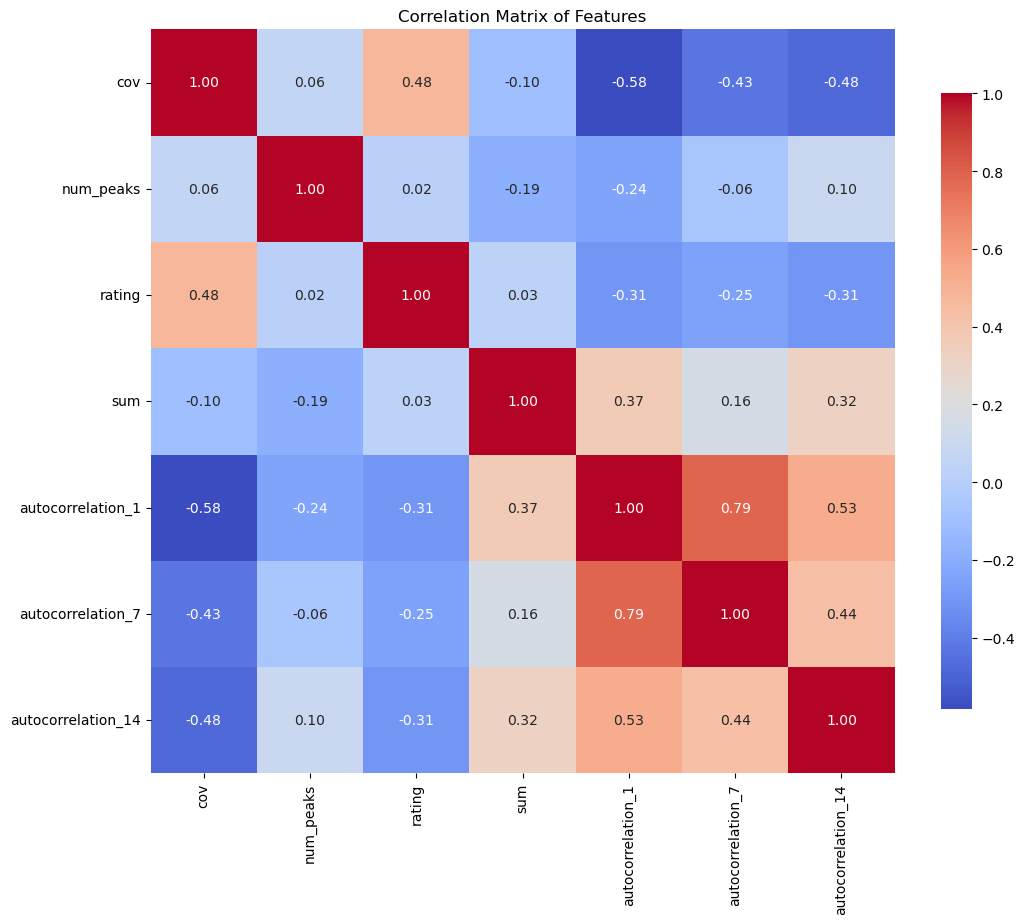

In [300]:
# plot correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(CF_Train[_cols].corr(method='spearman'), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.show()

In [301]:
# import minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# scale the CF_Train data
CF_Train_minmax = scaler.fit_transform(CF_Train[_cols])

# import standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# scale the CF_Train data
CF_Train_standard = scaler.fit_transform(CF_Train[_cols])

In [302]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def plot_kmeans_metrics(data, n_clusters_range=range(1, 15), n_init=80, random_state=42):
    """
    Esegue KMeans per un intervallo di cluster e plotta Inertia e SSE.

    Parameters:
    - data: array-like, dati scalati per il clustering.
    - n_clusters_range: range, intervallo di numero di cluster da testare.
    - n_init: int, numero di inizializzazioni per KMeans.
    - random_state: int, seed per la riproducibilità.

    Returns:
    - inertia: lista dei valori di Inertia per ogni numero di cluster.
    - sse: lista dei valori di SSE per ogni numero di cluster.
    """
    inertia = []
    sse = []

    for n_clusters in n_clusters_range:
        kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, random_state=random_state)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
        sse.append(kmeans.inertia_)

    # Plot Inertia
    plt.plot(n_clusters_range, inertia, marker='o')
    plt.title('KMeans Inertia vs Number of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.xticks(n_clusters_range)
    plt.grid()
    plt.show()

    # Plot SSE
    plt.plot(n_clusters_range, sse, marker='o')
    plt.title('KMeans SSE vs Number of Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('SSE')
    plt.xticks(n_clusters_range)
    plt.grid()
    plt.show()

    return inertia, sse

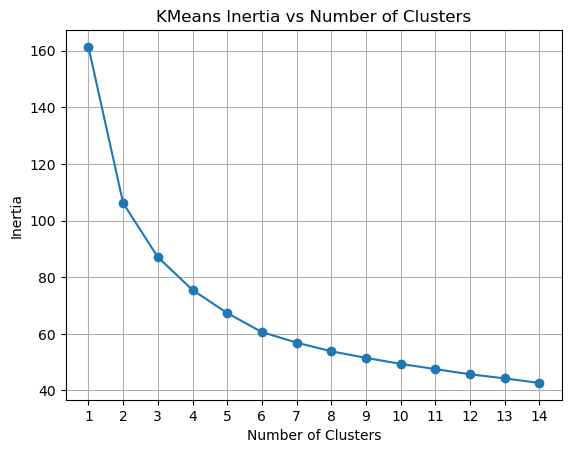

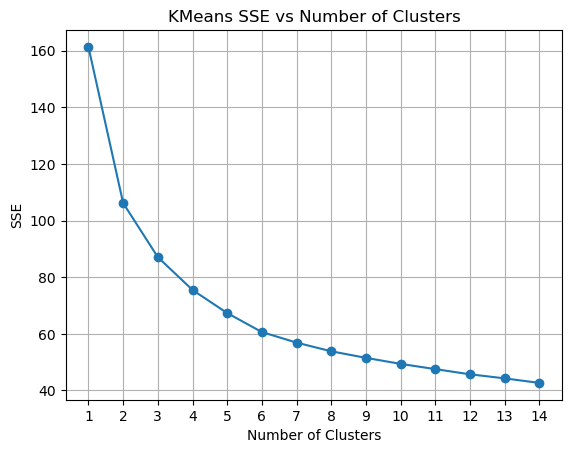

In [303]:
mm_inertia,mm_sse = plot_kmeans_metrics(CF_Train_minmax, n_clusters_range=range(1, 15), n_init=80, random_state=42)

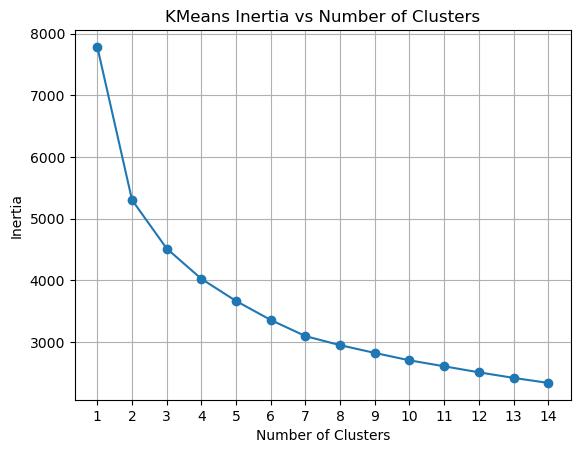

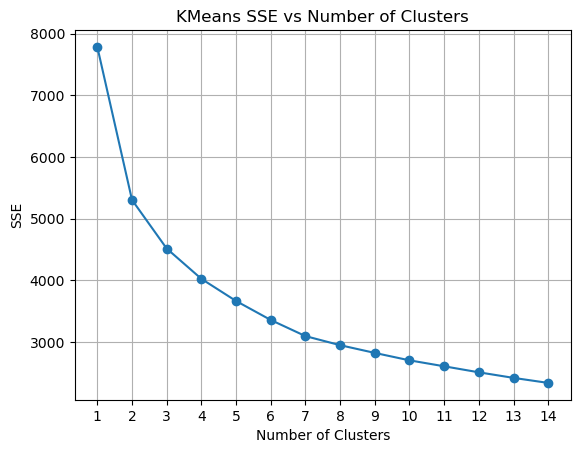

In [304]:
std_inertia, std_sse = plot_kmeans_metrics(CF_Train_standard, n_clusters_range=range(1, 15), n_init=80, random_state=42)

In [343]:
# k = 4 is the best 
kmeans = KMeans(n_clusters=3, n_init=300, random_state=42)

kmeans.fit(CF_Train_minmax)
# Add cluster labels to the original DataFrame
CF_Train['minMax_cluster'] = kmeans.labels_
# add cluster labels to TS_NO_OUTLIERS.csv
df['minMax_cluster'] = kmeans.labels_


kmeans.fit(CF_Train_standard)
# Add cluster labels to the original DataFrame
CF_Train['standard_cluster'] = kmeans.labels_
# add cluster labels to TS_NO_OUTLIERS.csv
df['standard_cluster'] = kmeans.labels_

In [344]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_clusters_rating_category(df, cluster_col):
    """
    Plots the distribution of rating categories for each cluster, both in absolute values, percentages per cluster, 
    and percentages relative to the entire dataset.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: str, name of the column containing cluster labels.
    """
    # Absolute values plot
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df, x=cluster_col, hue='rating_category', palette='viridis')
    plt.title(f'Distribution of Rating Categories by {cluster_col} (Absolute Values)')
    plt.xlabel(cluster_col)
    plt.ylabel('Count')
    plt.legend(title='Rating Category')

    # Add labels above bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=10, fontweight='bold', padding=3)

    # Customize axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Percentages per cluster plot
    plt.figure(figsize=(8, 4))
    # Calculate percentages per cluster
    cluster_counts = df.groupby([cluster_col, 'rating_category']).size().reset_index(name='count')
    cluster_totals = cluster_counts.groupby(cluster_col)['count'].transform('sum')
    cluster_counts['percentage'] = cluster_counts['count'] / cluster_totals * 100

    ax = sns.barplot(data=cluster_counts, x=cluster_col, y='percentage', hue='rating_category', palette='viridis')
    plt.title(f'Distribution of Rating Categories by {cluster_col} (Percentages per Cluster)')
    plt.xlabel(cluster_col)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Rating Category')

    # Add labels above bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

    # Customize axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Percentages relative to the entire dataset plot
    plt.figure(figsize=(8, 4))
    # Calculate percentages relative to the entire dataset
    total_counts = df.groupby(['rating_category', cluster_col]).size().reset_index(name='count')
    total_counts['percentage'] = total_counts['count'] / len(df) * 100

    ax = sns.barplot(data=total_counts, x=cluster_col, y='percentage', hue='rating_category', palette='viridis')
    plt.title(f'Distribution of Rating Categories by {cluster_col} (Percentages Relative to Entire Dataset)')
    plt.xlabel(cluster_col)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Rating Category')

    # Add labels above bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=10, fontweight='bold', padding=3)

    # Customize axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


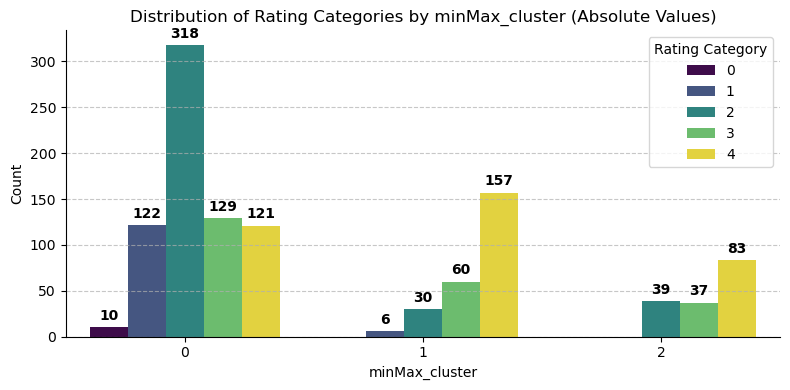

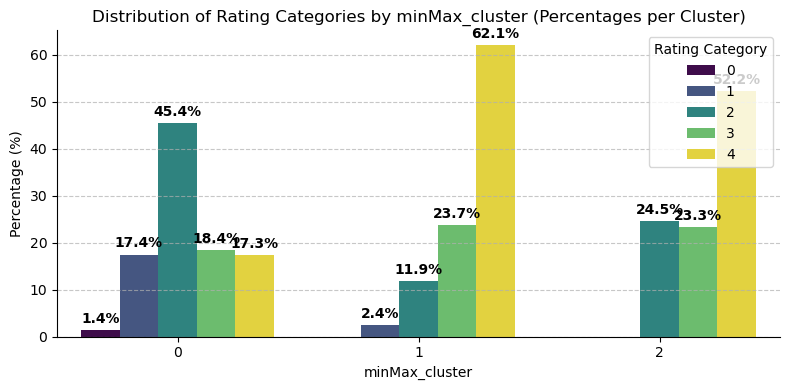

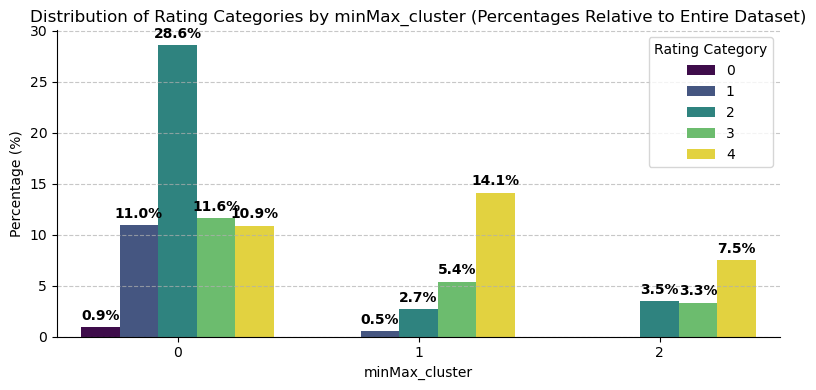

In [345]:

# Esempio di utilizzo
plot_clusters_rating_category(df, 'minMax_cluster')


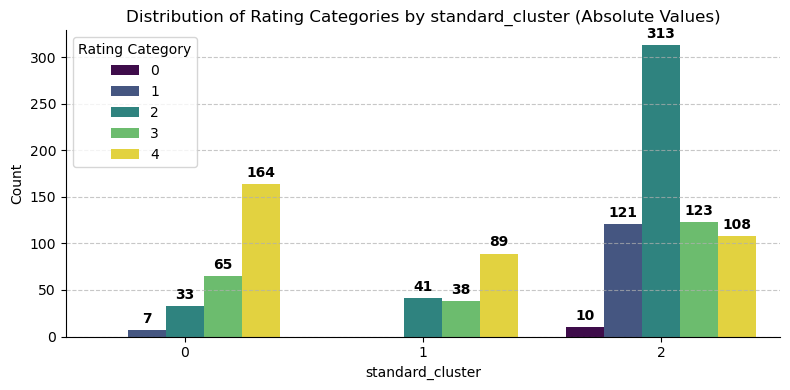

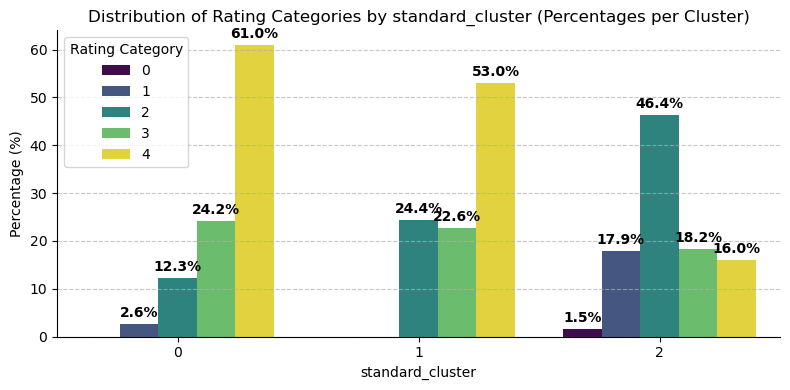

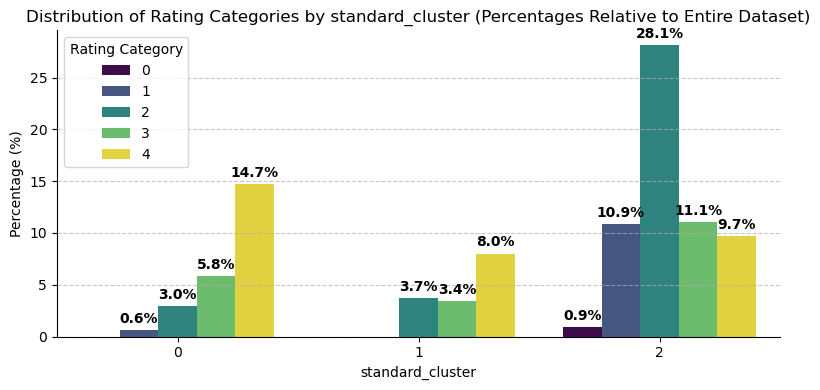

In [346]:
plot_clusters_rating_category(df, 'standard_cluster')

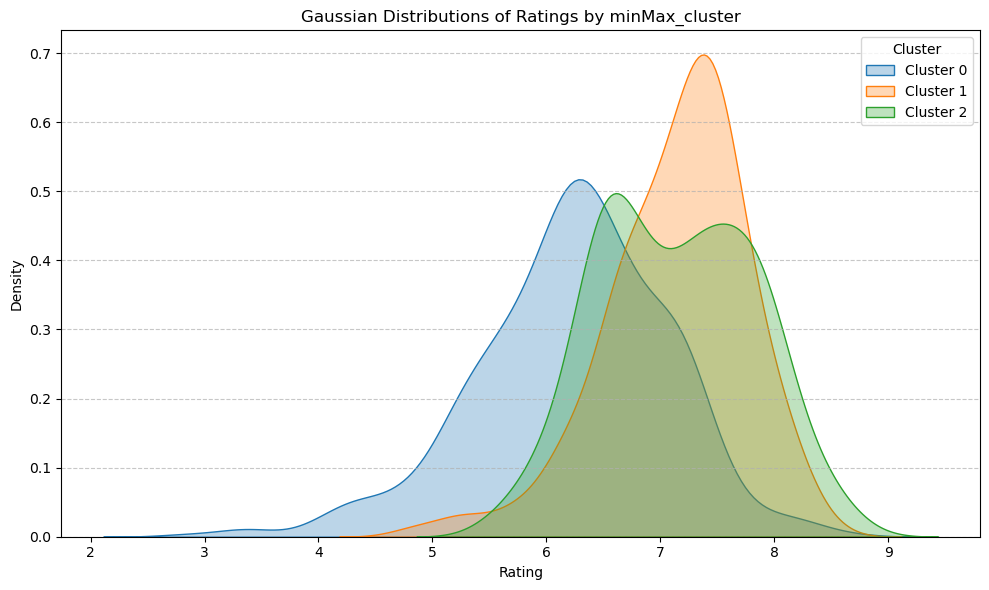

In [347]:
def plot_rating_gaussian_distribution(df, cluster_col):
    """
    Plots the Gaussian distributions (Kernel Density Estimation) of ratings for each cluster.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: str, name of the column containing cluster labels.
    """
    plt.figure(figsize=(10, 6))
    
    # Itera sui cluster unici
    for cluster in sorted(df[cluster_col].unique()):
        sns.kdeplot(
            data=df[df[cluster_col] == cluster]['rating'], 
            label=f'Cluster {cluster}', 
            fill=True, 
            alpha=0.3
        )
    
    plt.title(f'Gaussian Distributions of Ratings by {cluster_col}')
    plt.xlabel('Rating')
    plt.ylabel('Density')
    plt.legend(title='Cluster')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Esempio di utilizzo
plot_rating_gaussian_distribution(df, 'minMax_cluster')

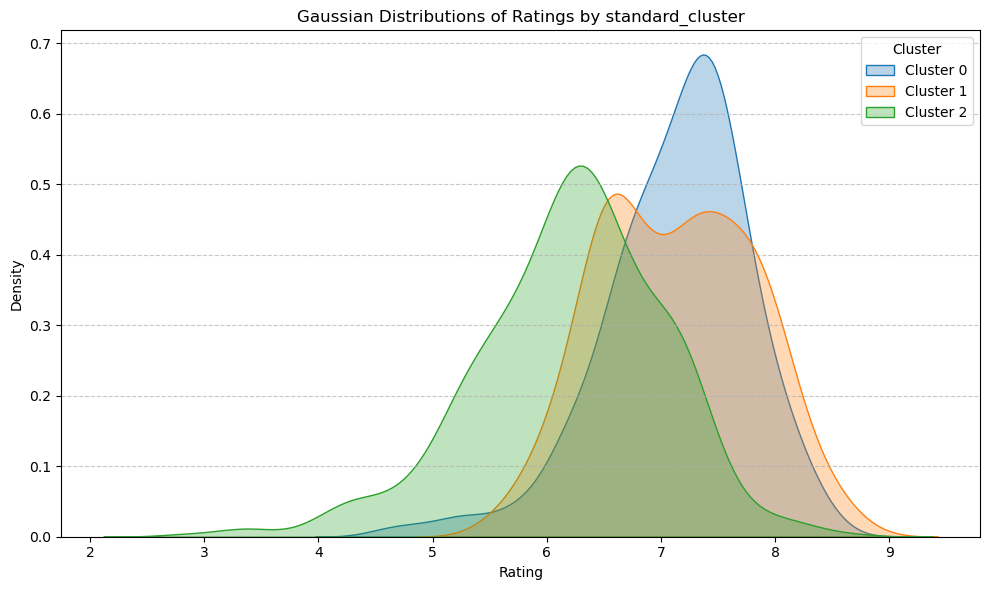

In [348]:
plot_rating_gaussian_distribution(df, 'standard_cluster')

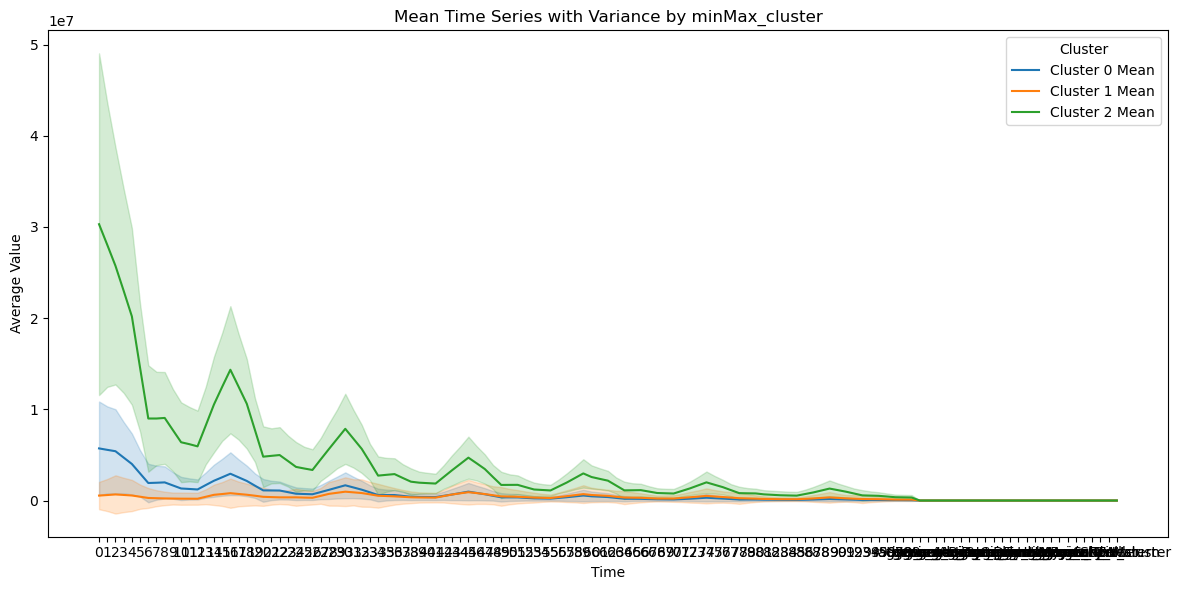

In [349]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_average_timeseries_with_variance(df, cluster_col):
    """
    Plots the average time series and highlights the variance for each cluster.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: str, name of the column containing cluster labels.
    """
    if cluster_col not in df.columns:
        raise ValueError(f"Column '{cluster_col}' not found in the DataFrame.")
    
    numeric_columns = df.select_dtypes(include=[np.number]).columns

    plt.figure(figsize=(12, 6))
    
    # Itera sui cluster unici
    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]
        avg_timeseries = cluster_data[numeric_columns].mean(axis=0)  # Calcola la media per ogni colonna numerica
        std_timeseries = cluster_data[numeric_columns].std(axis=0)   # Calcola la deviazione standard per ogni colonna numerica
        
        # Plot della media
        plt.plot(avg_timeseries, label=f'Cluster {cluster} Mean', color=f'C{cluster}')
        
        # Evidenzia la varianza con fill_between
        plt.fill_between(range(len(avg_timeseries)), 
                         avg_timeseries - std_timeseries, 
                         avg_timeseries + std_timeseries, 
                         alpha=0.2, color=f'C{cluster}')
    
    plt.title(f'Mean Time Series with Variance by {cluster_col}')
    plt.xlabel('Time')
    plt.ylabel('Average Value')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

# Carica il file CSV
df_clean = pd.read_csv('./TS_NO_OUTLIERS.csv')

# Aggiungi i cluster al DataFrame
df_clean['minMax_cluster'] = df['minMax_cluster'].values

# Esegui il plot
plot_average_timeseries_with_variance(df_clean, 'minMax_cluster')

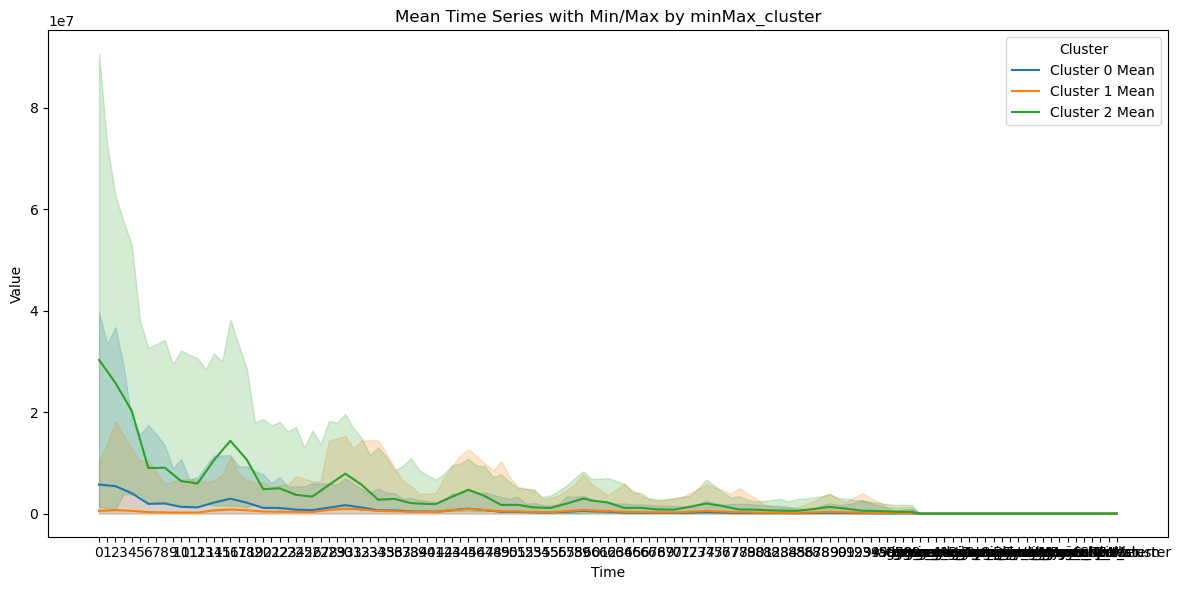

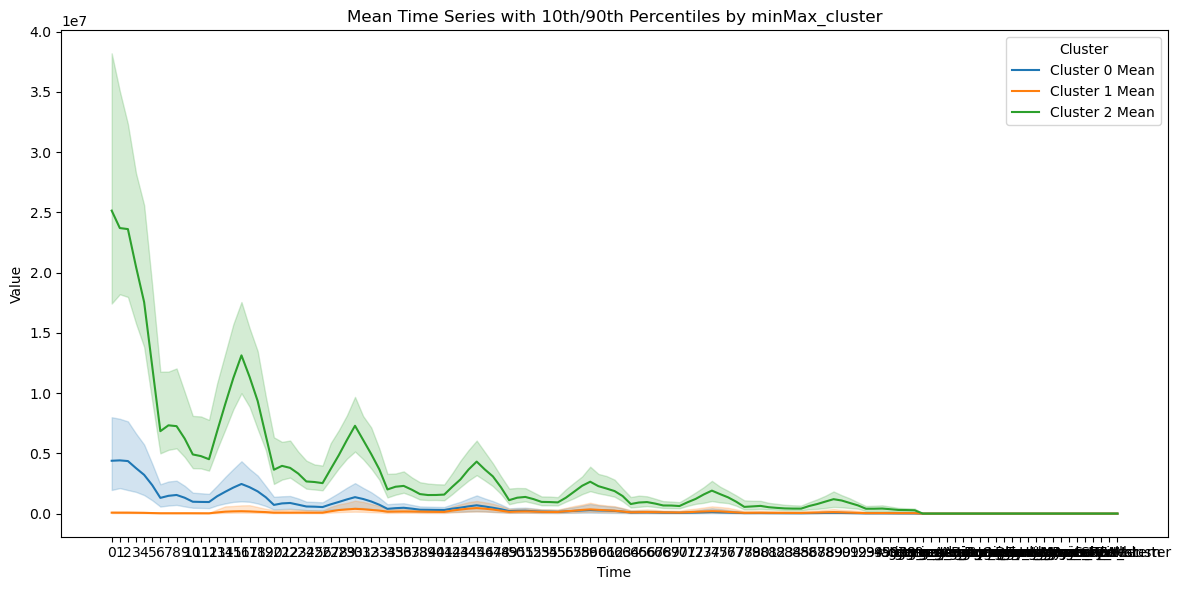

In [351]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_average_timeseries_with_min_max(df, cluster_col):
    """
    Plots the average time series for each cluster and highlights the min and max values.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: str, name of the column containing cluster labels.
    """
    if cluster_col not in df.columns:
        raise ValueError(f"Column '{cluster_col}' not found in the DataFrame.")
    
    numeric_columns = df.select_dtypes(include=[np.number]).columns

    plt.figure(figsize=(12, 6))
    
    # Itera sui cluster unici
    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]
        avg_timeseries = cluster_data[numeric_columns].mean(axis=0)  # Calcola la media per ogni colonna numerica
        min_timeseries = cluster_data[numeric_columns].min(axis=0)  # Calcola il valore minimo per ogni colonna numerica
        max_timeseries = cluster_data[numeric_columns].max(axis=0)  # Calcola il valore massimo per ogni colonna numerica
        
        # Plot della media
        plt.plot(avg_timeseries, label=f'Cluster {cluster} Mean', color=f'C{cluster}')
        
        # Evidenzia min e max con fill_between
        plt.fill_between(range(len(avg_timeseries)), 
                         min_timeseries, 
                         max_timeseries, 
                         alpha=0.2, color=f'C{cluster}')
    
    plt.title(f'Mean Time Series with Min/Max by {cluster_col}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

def plot_average_timeseries_with_percentiles(df, cluster_col, median = 0.5, first_percentile = 0.25, last_percentile = 0.75):
    """
    Plots the average time series for each cluster and highlights the 10th and 90th percentiles.

    Parameters:
    - df: DataFrame containing the data.
    - cluster_col: str, name of the column containing cluster labels.
    """
    if cluster_col not in df.columns:
        raise ValueError(f"Column '{cluster_col}' not found in the DataFrame.")
    
    numeric_columns = df.select_dtypes(include=[np.number]).columns

    plt.figure(figsize=(12, 6))
    
    # Itera sui cluster unici
    for cluster in sorted(df[cluster_col].unique()):
        cluster_data = df[df[cluster_col] == cluster]
        avg_timeseries = cluster_data[numeric_columns].quantile(median,axis=0)  # Calcola la media per ogni colonna numerica
        p10_timeseries = cluster_data[numeric_columns].quantile(first_percentile, axis=0)  # Calcola il 10° percentile
        p90_timeseries = cluster_data[numeric_columns].quantile(last_percentile, axis=0)  # Calcola il 90° percentile
        
        # Plot della media
        plt.plot(avg_timeseries, label=f'Cluster {cluster} Mean', color=f'C{cluster}')
        
        # Evidenzia 10° e 90° percentile con fill_between
        plt.fill_between(range(len(avg_timeseries)), 
                         p10_timeseries, 
                         p90_timeseries, 
                         alpha=0.2, color=f'C{cluster}')
    
    plt.title(f'Mean Time Series with 10th/90th Percentiles by {cluster_col}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()

# Carica il file CSV
df_clean = pd.read_csv('./TS_NO_OUTLIERS.csv')

# Aggiungi i cluster al DataFrame
df_clean['minMax_cluster'] = df['minMax_cluster'].values

# Esegui il plot con min/max
plot_average_timeseries_with_min_max(df_clean, 'minMax_cluster')

# Esegui il plot con 10° e 90° percentile
plot_average_timeseries_with_percentiles(df_clean, 'minMax_cluster')

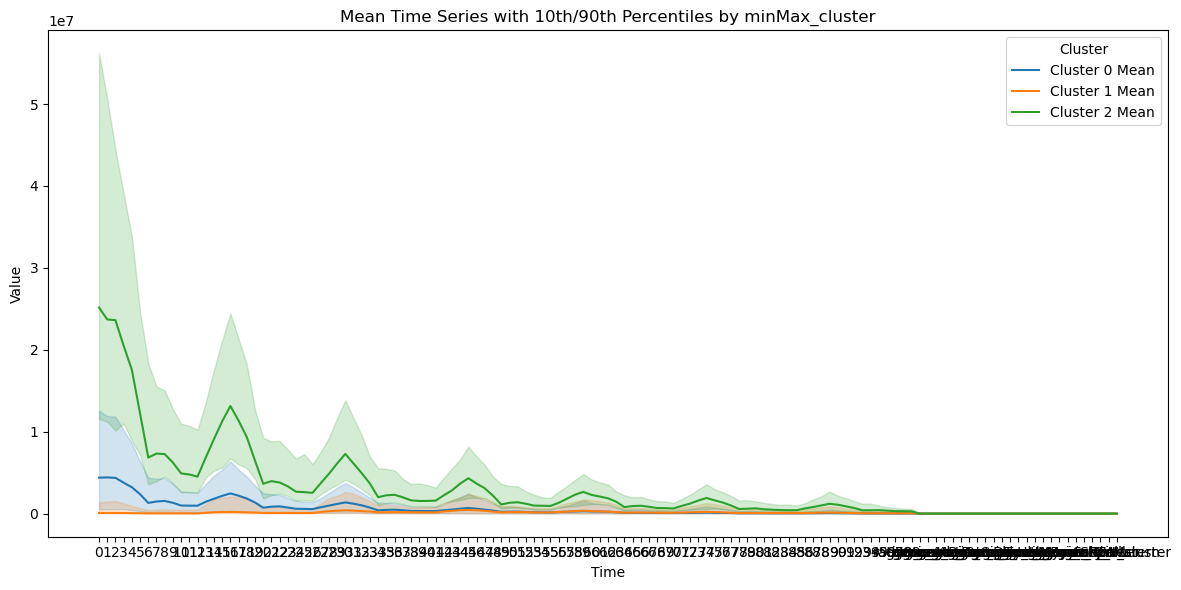

In [354]:
plot_average_timeseries_with_percentiles(df_clean, 'minMax_cluster', median = 0.5, first_percentile = 0.1, last_percentile = 0.9)
